In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
weights_ref = models.EfficientNet_B0_Weights.IMAGENET1K_V1
model = models.efficientnet_b0(weights=weights_ref)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.6),
    nn.Linear(in_features=1280, out_features=4, bias=True)
)

model.load_state_dict(torch.load(
    '/home/sagemaker-user/NeuroVision/best_weights.pth',
    map_location=device
))
model = model.to(device)
model.eval()
print("EfficientNet-B0 loaded")
print(f"Target layer: {model.features[-1]}")

EfficientNet-B0 loaded ✓
Target layer: Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)


In [3]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        
        # Register hooks
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        
        # Backprop for target class
        score = output[0, class_idx]
        score.backward()
        
        # Pool gradients across channels
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam)
        cam     = cam.squeeze().cpu().numpy()
        
        # Normalise to 0-1
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx, output.softmax(dim=1).detach().cpu().numpy()[0]

# Initialise Grad-CAM on final conv block
gradcam = GradCAM(model, model.features[-1])
print("Grad-CAM ready")

Grad-CAM ready ✓


In [4]:
CLASS_NAMES = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

# Use EfficientNet's own preprocessing (matches Khoi's training)
preprocess = models.EfficientNet_B0_Weights.IMAGENET1K_V1.transforms()

def run_gradcam(image_path, save_path=None):
    # Load original image
    orig = Image.open(image_path).convert('RGB')
    orig_np = np.array(orig.resize((224, 224))) / 255.0

    # Preprocess for model
    input_tensor = preprocess(orig).unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)

    # Run Grad-CAM
    cam, pred_idx, probs = gradcam.generate(input_tensor)

    # Resize CAM to 224x224
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    # Overlay
    overlay = 0.5 * orig_np + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(orig_np);          axes[0].set_title('Original MRI');      axes[0].axis('off')
    axes[1].imshow(cam_resized, cmap='jet'); axes[1].set_title('Grad-CAM Heatmap'); axes[1].axis('off')
    axes[2].imshow(overlay);          axes[2].set_title(f'Overlay\nPred: {CLASS_NAMES[pred_idx]} ({probs[pred_idx]*100:.1f}%)'); axes[2].axis('off')

    plt.suptitle(f'Prediction: {CLASS_NAMES[pred_idx]} | Confidence: {probs[pred_idx]*100:.1f}%', fontsize=13)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nPredicted: {CLASS_NAMES[pred_idx]} ({probs[pred_idx]*100:.1f}%)")
    print("All probabilities:")
    for i, cls in enumerate(CLASS_NAMES):
        print(f"  {cls}: {probs[i]*100:.2f}%")

    return cam_resized, pred_idx, probs

print("Visualisation helper ready")

Visualisation helper ready ✓


Testing on: /home/sagemaker-user/dataset_classification/Testing/glioma_tumor/image(1).jpg


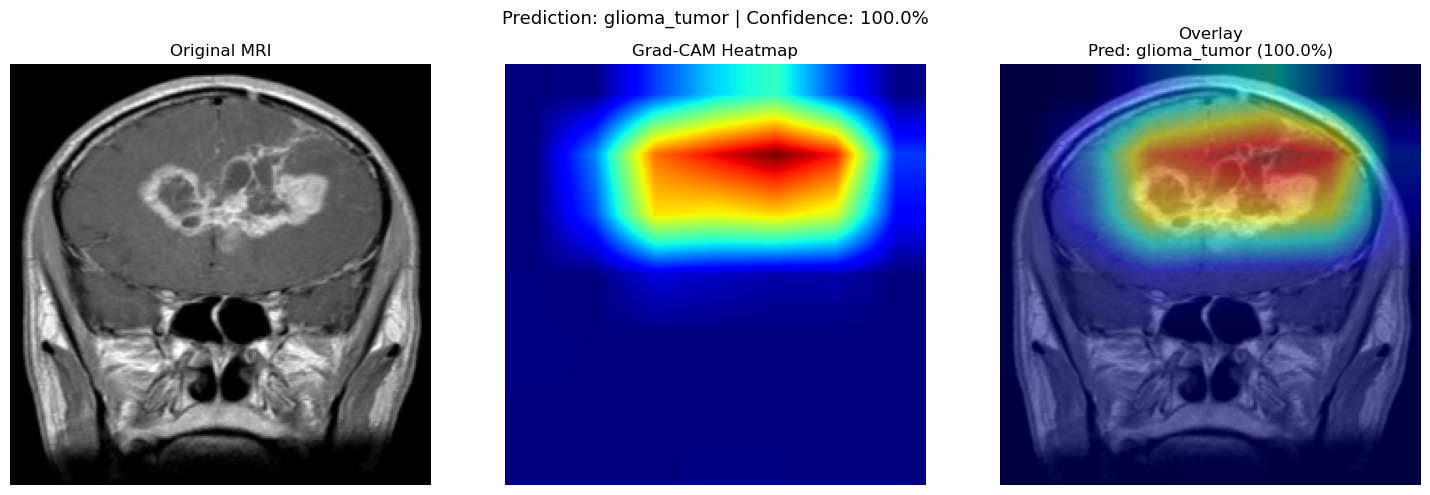


Predicted: glioma_tumor (100.0%)
All probabilities:
  glioma_tumor: 99.99%
  meningioma_tumor: 0.01%
  no_tumor: 0.00%
  pituitary_tumor: 0.00%


In [5]:
# Pick one image from each class to test
test_images = {
    'glioma':     '/home/sagemaker-user/dataset_classification/Testing/glioma_tumor',
    'meningioma': '/home/sagemaker-user/dataset_classification/Testing/meningioma_tumor',
    'no_tumor':   '/home/sagemaker-user/dataset_classification/Testing/no_tumor',
    'pituitary':  '/home/sagemaker-user/dataset_classification/Testing/pituitary_tumor',
}

# Run on first image from glioma class
glioma_dir   = test_images['glioma']
sample_image = os.path.join(glioma_dir, os.listdir(glioma_dir)[0])
print(f"Testing on: {sample_image}")

cam, pred, probs = run_gradcam(
    sample_image,
    save_path='/home/sagemaker-user/NeuroVision/gradcam_sample_glioma.png'
)


Class: glioma


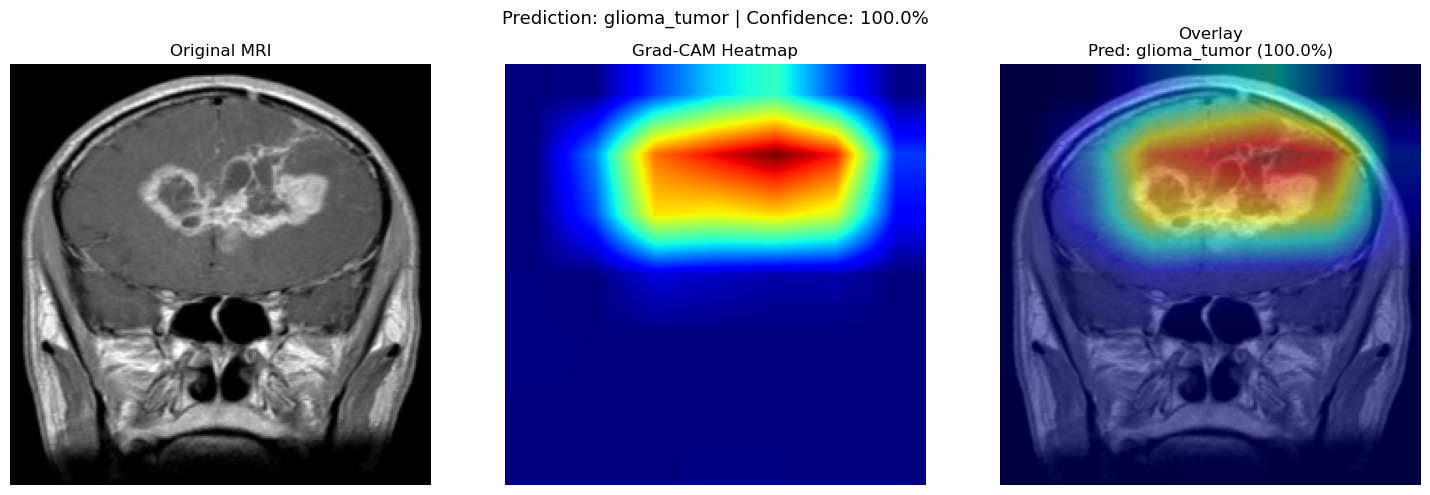


Predicted: glioma_tumor (100.0%)
All probabilities:
  glioma_tumor: 99.99%
  meningioma_tumor: 0.01%
  no_tumor: 0.00%
  pituitary_tumor: 0.00%

Class: meningioma


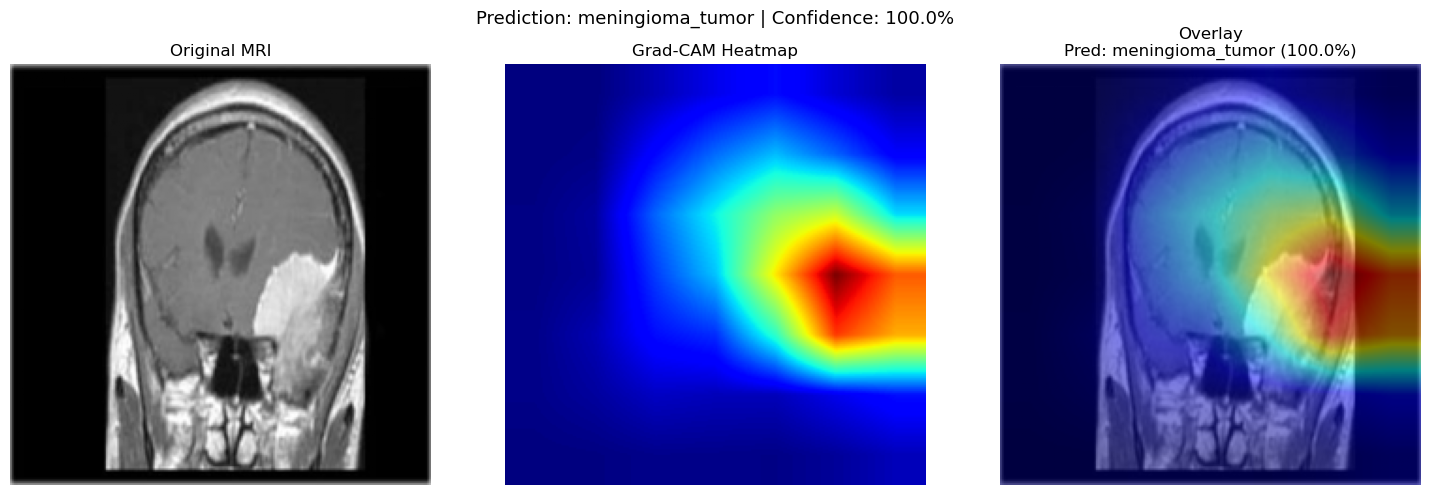


Predicted: meningioma_tumor (100.0%)
All probabilities:
  glioma_tumor: 0.01%
  meningioma_tumor: 99.96%
  no_tumor: 0.02%
  pituitary_tumor: 0.02%

Class: no_tumor


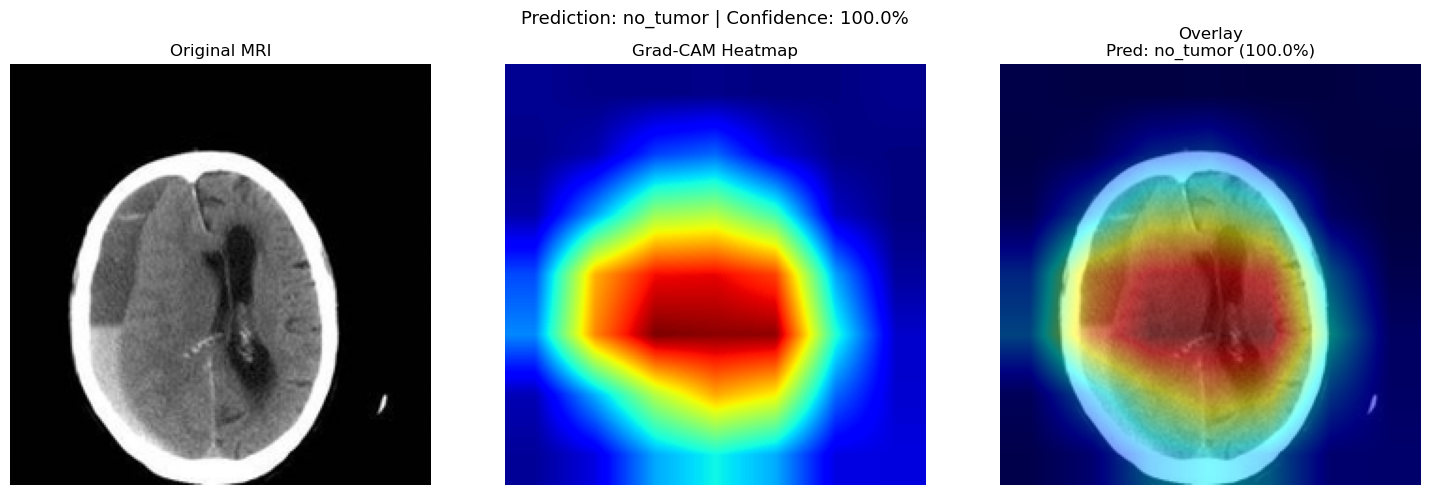


Predicted: no_tumor (100.0%)
All probabilities:
  glioma_tumor: 0.00%
  meningioma_tumor: 0.01%
  no_tumor: 99.99%
  pituitary_tumor: 0.00%

Class: pituitary


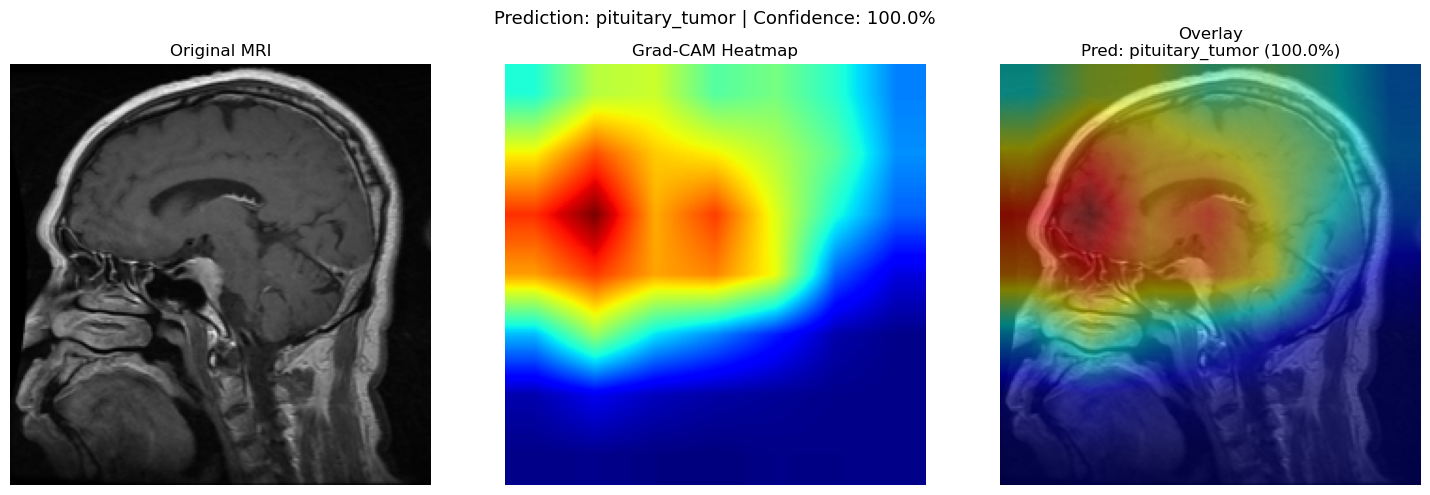


Predicted: pituitary_tumor (100.0%)
All probabilities:
  glioma_tumor: 0.00%
  meningioma_tumor: 0.00%
  no_tumor: 0.00%
  pituitary_tumor: 100.00%


In [6]:
# Run Grad-CAM on one sample from each class
for cls_name, cls_path in test_images.items():
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    sample = os.path.join(cls_path, files[0])
    print(f"Class: {cls_name}")
    cam, pred, probs = run_gradcam(
        sample,
        save_path=f'/home/sagemaker-user/NeuroVision/gradcam_{cls_name}.png'
    )